In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/samplesuperstore/SampleSuperstore.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [3]:
filepath = "/kaggle/input/samplesuperstore/SampleSuperstore.csv"
df_store = pd.read_csv(filepath, skipinitialspace = True).drop(["Country", "Postal Code"], axis = 1)
df_store

,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...
9988,Standard Class,Corporate,Athens,Georgia,South,Technology,Phones,206.1000,5,0.00,55.6470
9989,Second Class,Consumer,Miami,Florida,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,Costa Mesa,California,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,Costa Mesa,California,West,Technology,Phones,258.5760,2,0.20,19.3932


In [4]:
df_store.dtypes

Ship Mode        object
Segment          object
City             object
State            object
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [5]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   City          9993 non-null   object 
 3   State         9993 non-null   object 
 4   Region        9993 non-null   object 
 5   Category      9993 non-null   object 
 6   Sub-Category  9993 non-null   object 
 7   Sales         9993 non-null   float64
 8   Quantity      9993 non-null   int64  
 9   Discount      9993 non-null   float64
 10  Profit        9993 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 858.9+ KB


### Profit of each Category

In [6]:
df_category = df_store.groupby(["Category"])["Profit"].sum()
df_category

Category
Furniture           18451.2728
Office Supplies    122417.8528
Technology         145454.9481
Name: Profit, dtype: float64

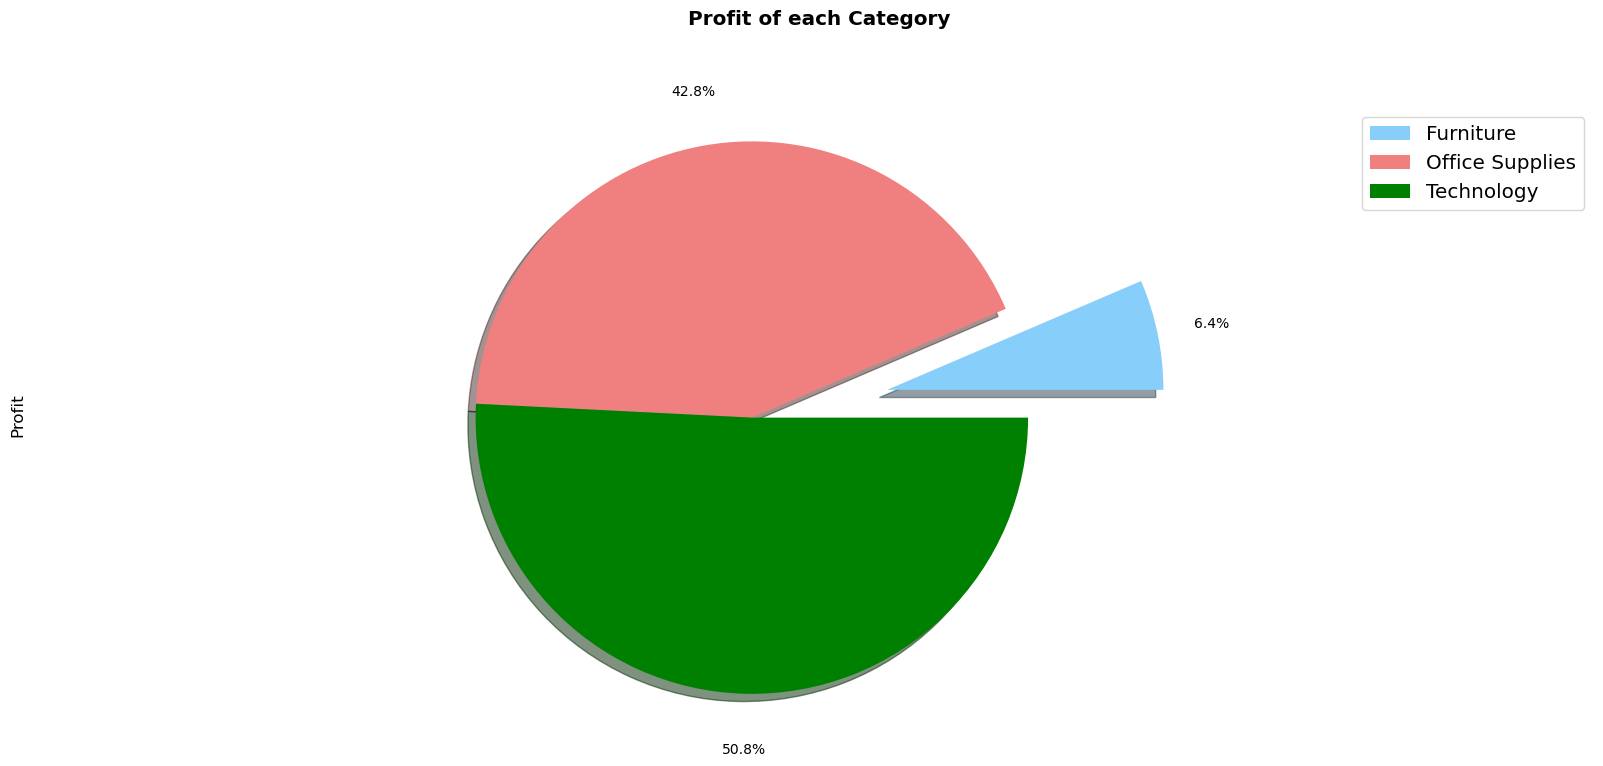

In [7]:
df_category.plot(kind = "pie", figsize = (20, 8),
                autopct = "%.1f%%",
                pctdistance = 1.2,
                startangle = 0, 
                labels = None, 
                shadow = True, 
                colors = ["lightskyblue", "lightcoral", "green"],
                explode = [0.5, 0, 0],
                textprops = {"fontsize":10})

plt.title("Profit of each Category", y = 1.12, fontweight = "bold", fontsize = "x-large")
plt.ylabel("Profit", labelpad = 10, fontsize = "large")
plt.legend(labels = df_category.index, loc = "upper right", fontsize = "x-large")
plt.axis("equal")

plt.show()

### Profit of each Sub-Category

In [8]:
df_sub_category = df_store.groupby(["Sub-Category"])["Profit"].sum()
df_sub_category = pd.DataFrame(df_sub_category).reset_index()
df_sub_category

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18065.0574
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


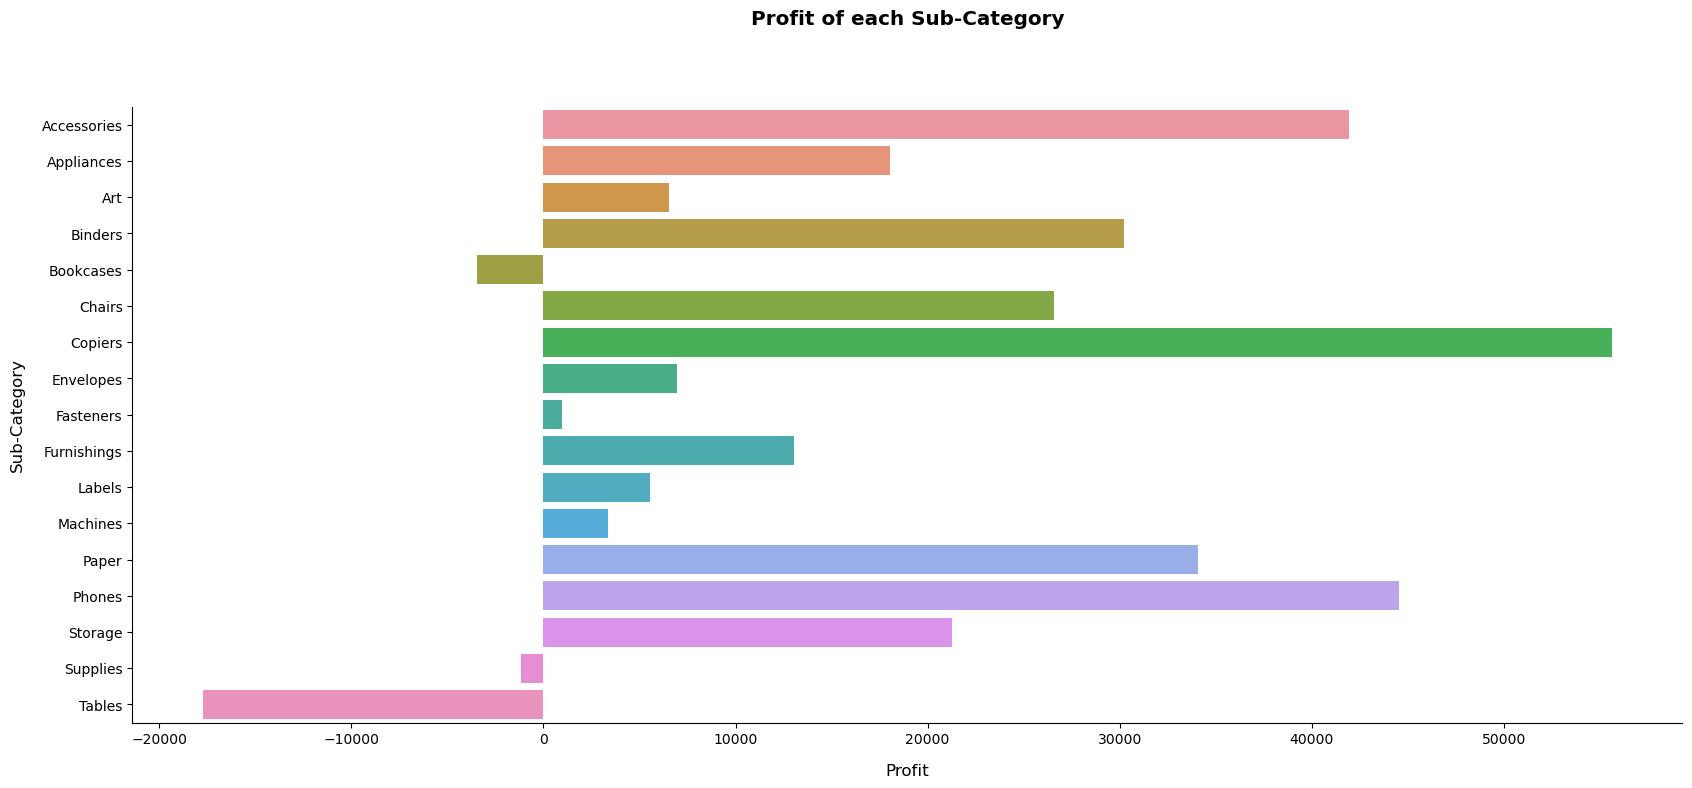

In [9]:
plt.figure(figsize = (20, 8))
sns.barplot(data = df_sub_category, x = "Profit", y = "Sub-Category")


plt.title("Profit of each Sub-Category", y = 1.12, fontweight = "bold", fontsize = "x-large")
plt.ylabel("Sub-Category", labelpad= 12, fontsize = "large")
plt.xlabel("Profit", labelpad = 12, fontsize = "large")

sns.set_style("whitegrid")
sns.despine()

### Profits come from the 10 largest states in the USA

In [10]:
df_store = df_store.groupby(["State"])["Profit"].sum()
df_state = pd.DataFrame(df_store)

df_state10 = df_state.loc[["Washington", "Mississippi",
                          "Ohio", "Georgia", "Texas", "California", "New York",
                          "Pennsylvania", "Massachusetts", "Florida"], :]

df_state10

,Profit
State,
Washington,33402.6517
Mississippi,3172.9762
Ohio,-16971.3766
Georgia,16250.0433
Texas,-25729.3563
California,76308.4391
New York,74038.5486
Pennsylvania,-15559.9603
Massachusetts,6785.5016


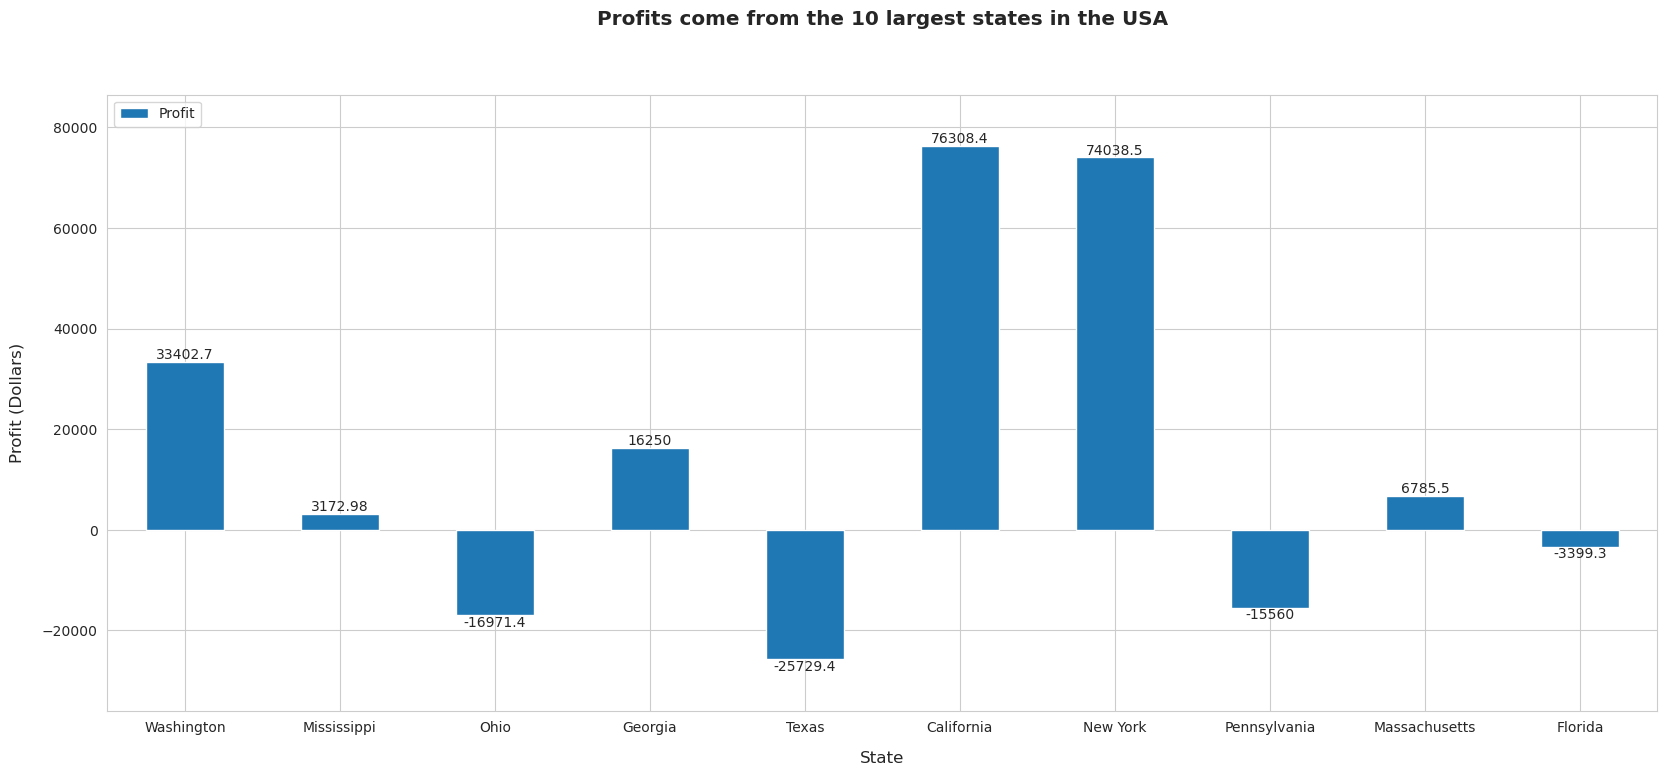

In [11]:
ax = df_state10.plot(kind = "bar", rot = 0, figsize = (20, 8))

ax.set_title("Profits come from the 10 largest states in the USA", y = 1.1, fontweight = "bold", fontsize = "x-large")
ax.set_xlabel("State", fontsize = "large", labelpad = 12)
ax.set_ylabel("Profit (Dollars)", labelpad = 12, fontsize = "large")

ax.bar_label(ax.containers[0], label_type = "edge")
ax.margins(y = 0.1)

plt.legend(loc = "upper left")
plt.show()

### Sub-Category and Profit, through the relationship of Region, Segment

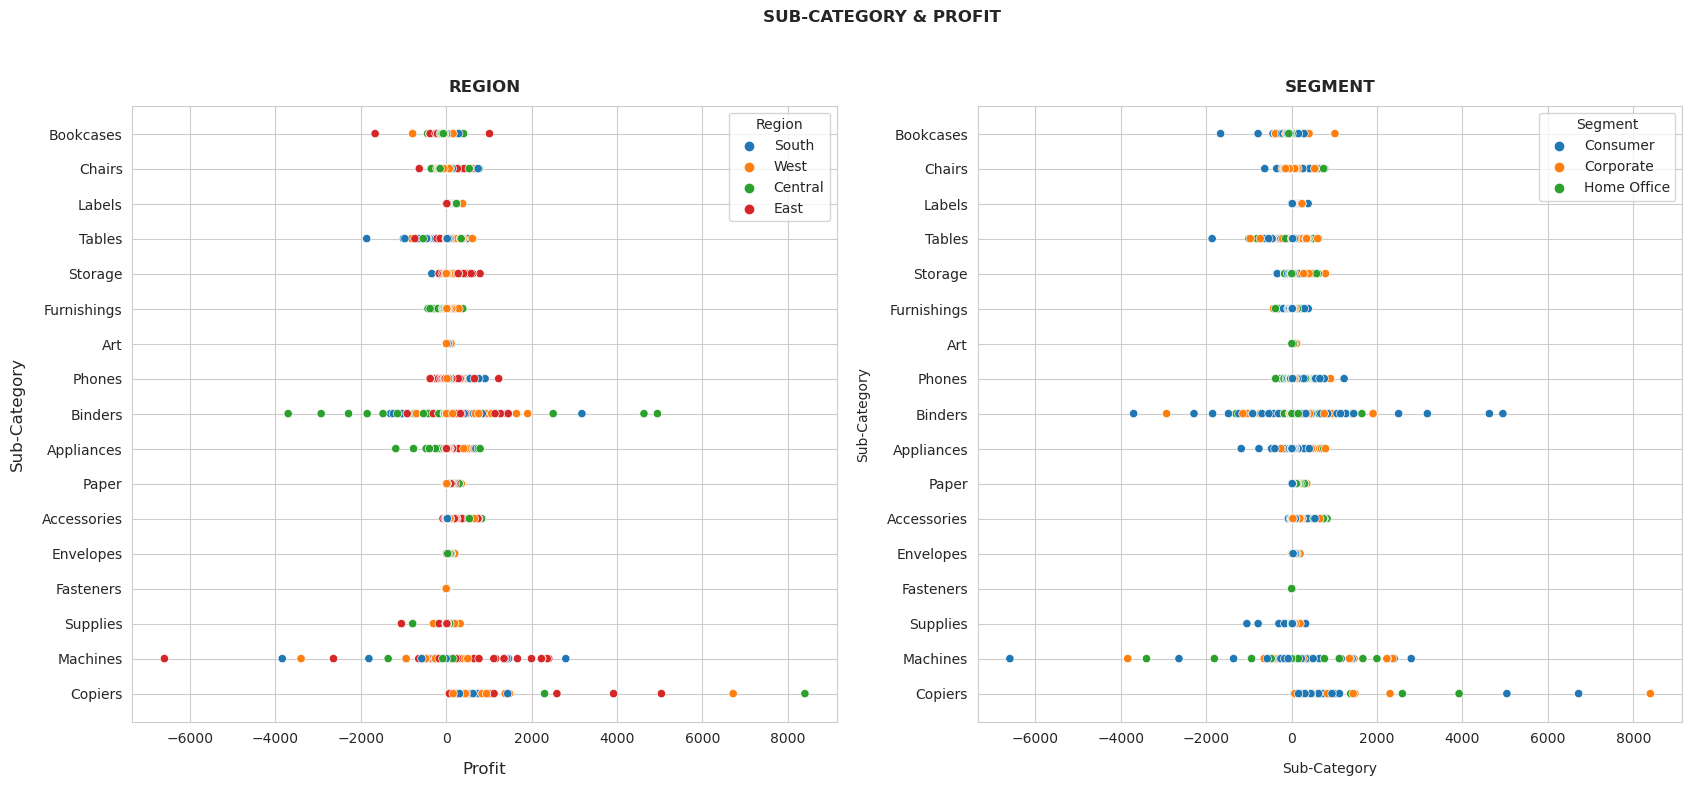

In [12]:
df_store = pd.read_csv(filepath, skipinitialspace = True).drop(["Country", "Postal Code"], axis = 1)


fig = plt.figure(figsize = (20, 8))
fig.suptitle("SUB-CATEGORY & PROFIT", y = 1, fontweight = "bold")

ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.scatterplot(data = df_store, y = "Sub-Category", x = "Profit", hue = "Region", ax = ax0)
ax0.set_ylabel("Sub-Category", labelpad = 12, fontsize = "large")
ax0.set_xlabel("Profit", labelpad = 12, fontsize = "large")
ax0.set_title("REGION", y = 1.01,fontweight = "bold")

sns.scatterplot(data = df_store, y = "Sub-Category", x = "Profit", hue = "Segment", ax = ax1)
ax1.set_ylabel("Sub-Category", labelpad = 12)
ax1.set_xlabel("Sub-Category", labelpad = 12)
ax1.set_title("SEGMENT", y = 1.01, fontweight = "bold")

plt.show()

### All State in the dataset

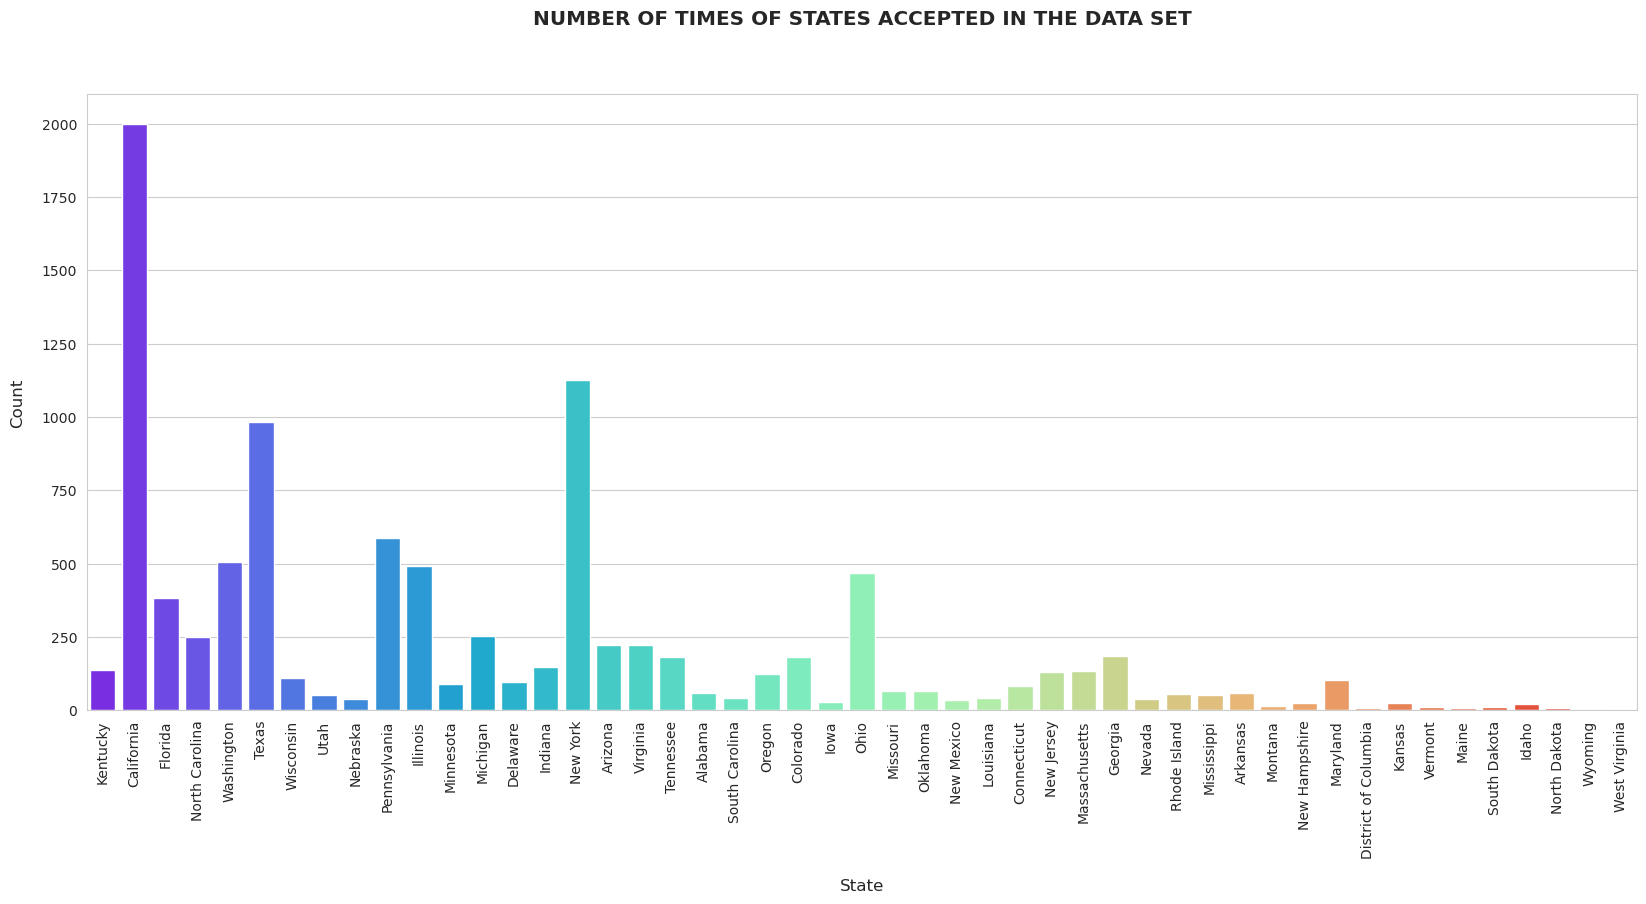

In [13]:
df_store = pd.read_csv(filepath, skipinitialspace = True).drop(["Country", "Postal Code"], axis = 1)

plt.figure(figsize = (20, 8))
sns.countplot(data = df_store, x = "State", palette = "rainbow")
plt.xticks(rotation = 90)

plt.title("NUMBER OF TIMES OF STATES ACCEPTED IN THE DATA SET", y = 1.1, fontsize = "x-large", fontweight = "bold")
plt.ylabel("Count", labelpad = 12, fontsize = "large")
plt.xlabel("State", labelpad = 15, fontsize = "large")

plt.show()

### Average Profits and Sales across 52 US States

In [14]:
df_sales_profit = df_store.groupby(["State"])[["Sales", "Profit"]].mean()
df_sales_profit

,Sales,Profit
State,,
Alabama,319.846557,94.865989
Arizona,157.508933,-15.303235
Arkansas,194.635500,66.811452
California,228.722236,38.154220
Colorado,176.418231,-35.867351
Connecticut,163.223866,42.823071
Delaware,285.948635,103.930988
District of Columbia,286.502000,105.958930
Florida,233.612815,-8.875461


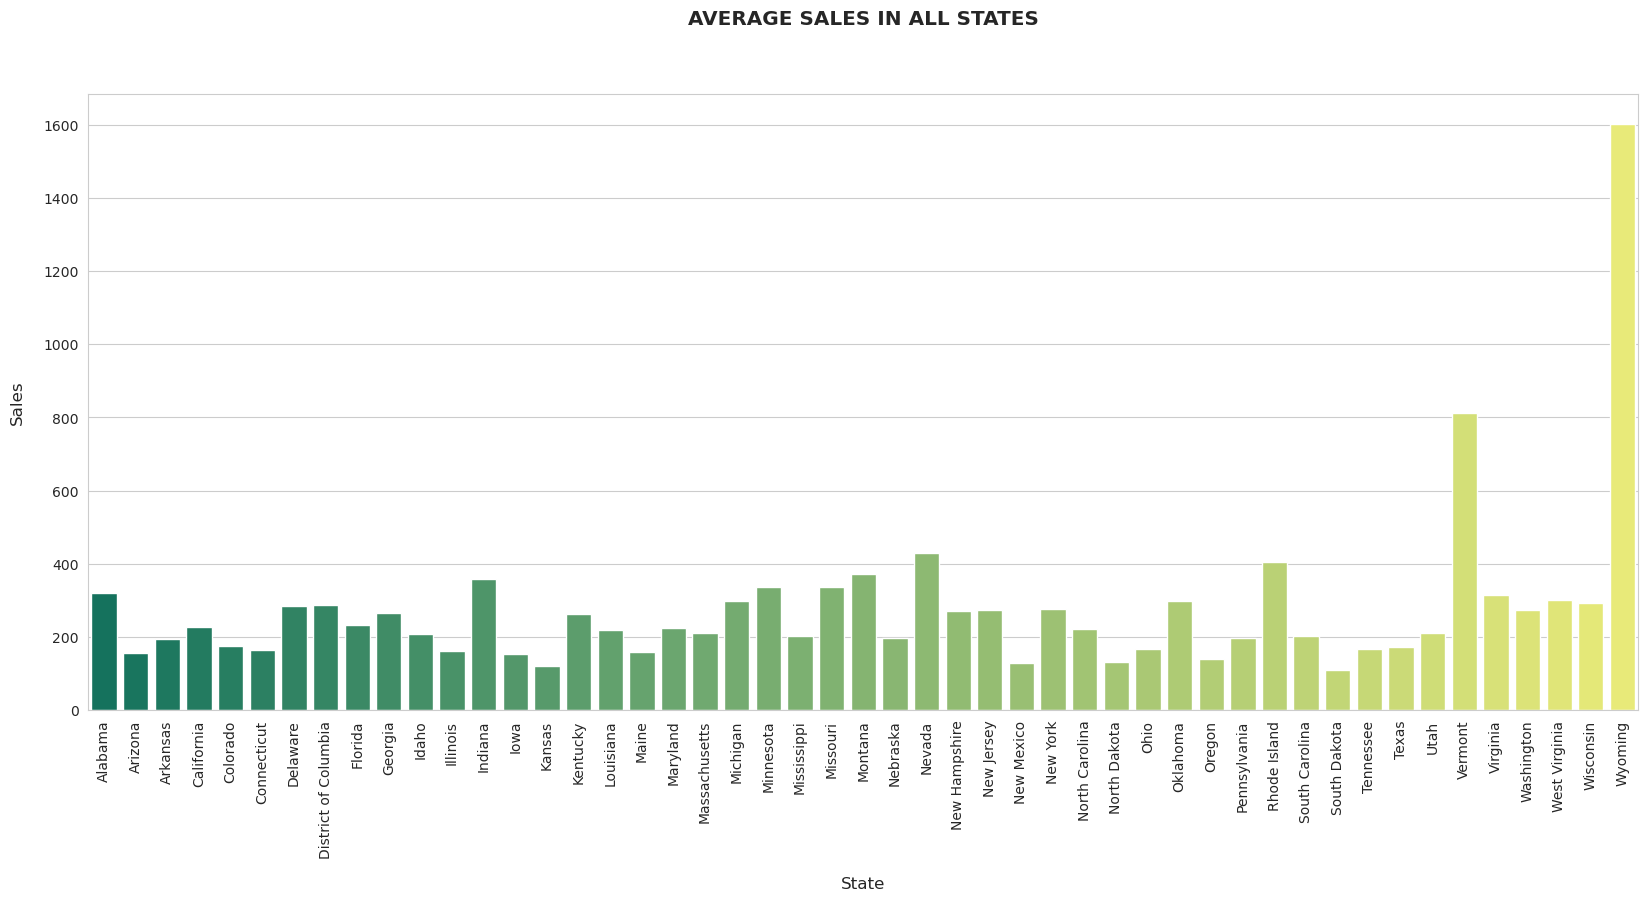

In [15]:
plt.figure(figsize = (20, 8))
sns.barplot(data = df_sales_profit, x = df_sales_profit.index, y = "Sales", palette = "summer")

plt.xticks(rotation = 90)
plt.title("AVERAGE SALES IN ALL STATES", y = 1.1, fontsize = "x-large", fontweight = "bold")
plt.xlabel("State", fontsize = "large", labelpad = 13)
plt.ylabel("Sales", fontsize = "large", labelpad = 13)

plt.show()

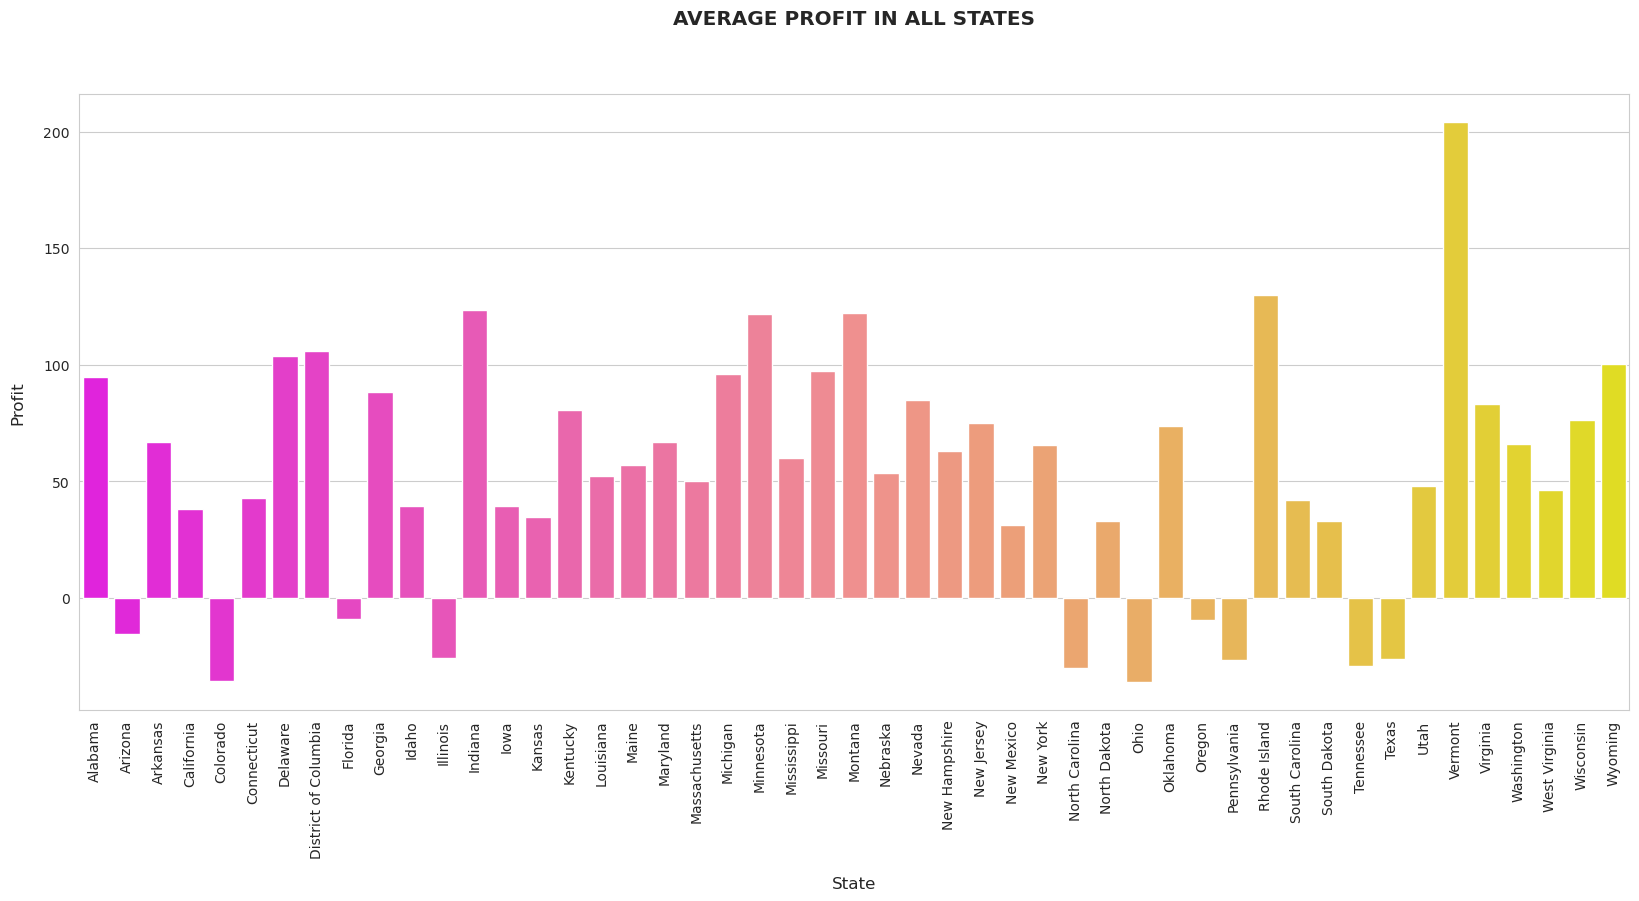

In [16]:
plt.figure(figsize = (20, 8))
sns.barplot(data = df_sales_profit, x = df_sales_profit.index, y = "Profit", palette = "spring")

plt.xticks(rotation = 90)
plt.xlabel("State", fontsize = "large", labelpad = 13)
plt.ylabel("Profit", fontsize = "large", labelpad = 13)
plt.title("AVERAGE PROFIT IN ALL STATES", y = 1.1, fontsize = "x-large", fontweight = "bold")

plt.show()

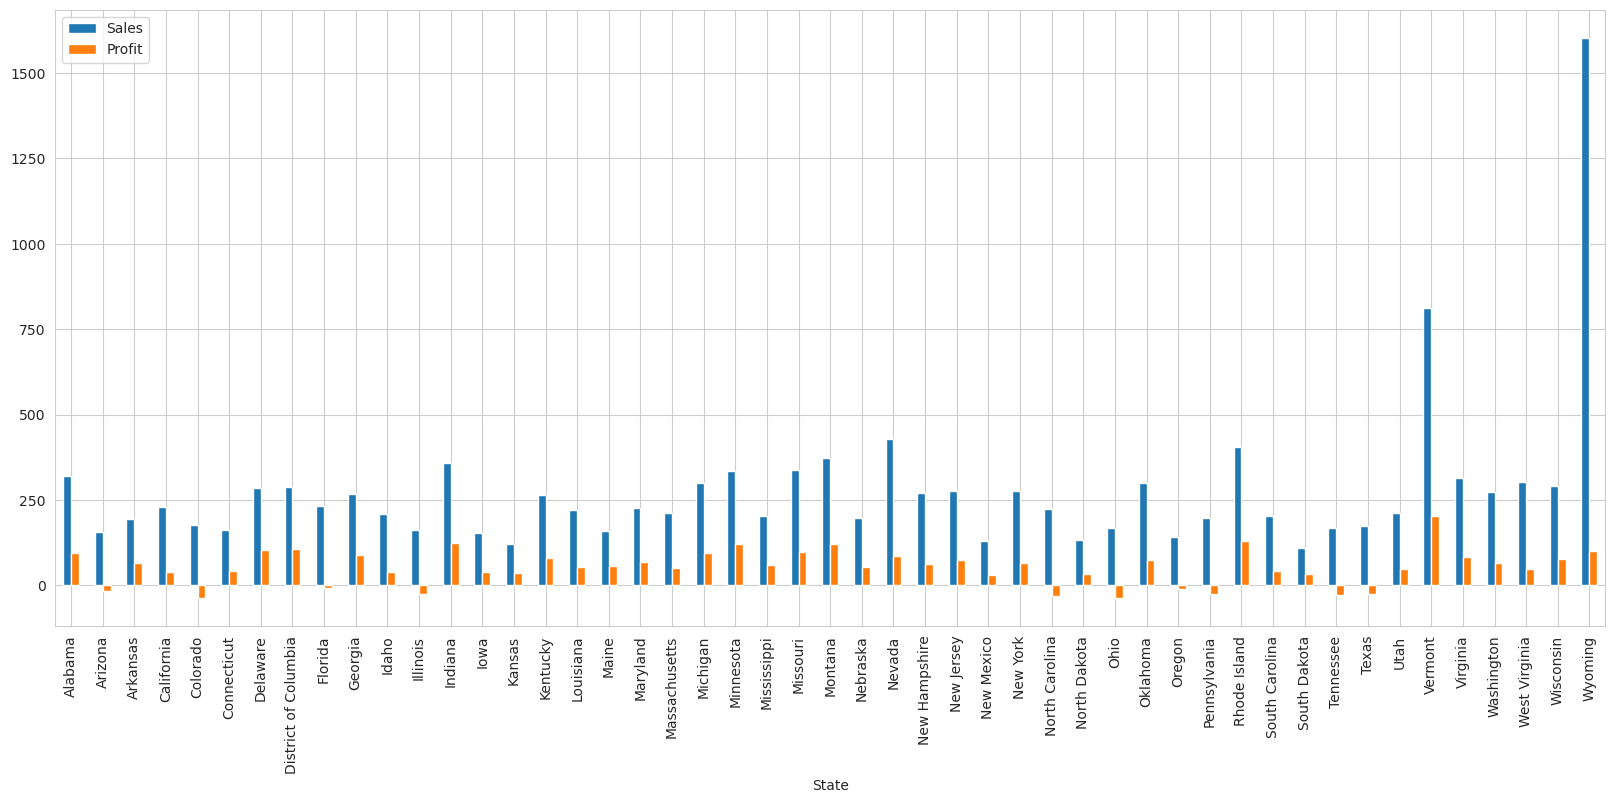

In [17]:
df_sales_profit.plot(kind = "bar", rot = 90, figsize = (20, 8))
plt.show()

### The relationship between (Profit, Quantity, Sales, Discounts)

In [18]:
df_store = df_store.loc[:, ["Sales", "Profit", "Quantity", "Discount"]]
df_4 = df_store.corr()
df_4

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479065,0.200803,-0.028189
Profit,0.479065,1.000000,0.066271,-0.219480
Quantity,0.200803,0.066271,1.000000,0.008563
Discount,-0.028189,-0.219480,0.008563,1.000000


<AxesSubplot:>

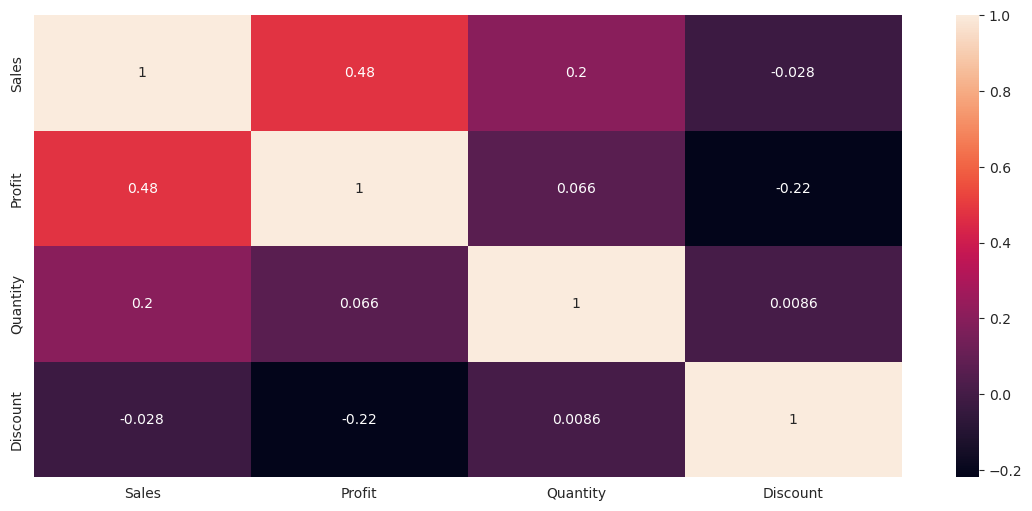

In [19]:
plt.figure(figsize = (14, 6))
sns.heatmap(df_4, annot = True)

### Correlation between Profit and Revenue across 4 regions

In [20]:
df_store = pd.read_csv(filepath, skipinitialspace = True).drop(["Country", "Postal Code"], axis = 1)
df = df_store.groupby(["Region"])[["Sales", "Profit"]].sum()
df = pd.DataFrame(df).reset_index()
df

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725214.6645,108345.5009


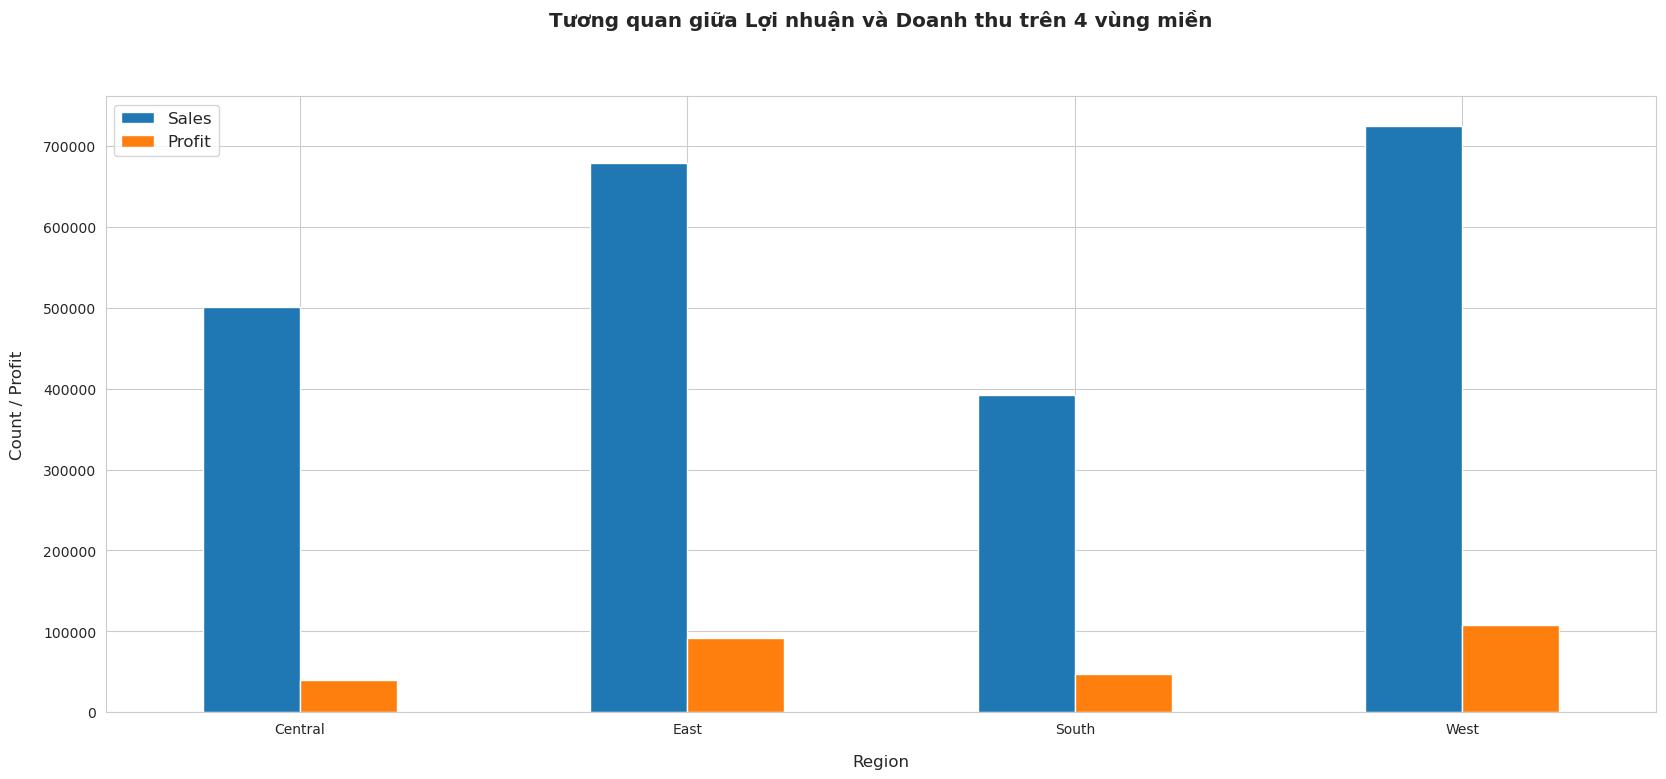

In [21]:
df.plot(kind = "bar", x = "Region", figsize = (20, 8), rot = 0)

plt.title("Tương quan giữa Lợi nhuận và Doanh thu trên 4 vùng miền", y = 1.1, fontweight = "bold", fontsize = "x-large")
plt.xlabel("Region", labelpad = 13, fontsize = "large")
plt.ylabel("Count / Profit",labelpad = 13, fontsize = "large")
plt.legend(loc = "upper left", fontsize = "large")
plt.show()

### Quantity from each Sub-Category 

In [22]:
df_store = pd.read_csv(filepath, skipinitialspace = True).drop(["Country", "Postal Code"], axis = 1)
df = df_store.groupby(["Sub-Category"])["Quantity"].sum()
df = pd.DataFrame(df).reset_index()
df

,Sub-Category,Quantity
0,Accessories,2976
1,Appliances,1727
2,Art,3000
3,Binders,5974
4,Bookcases,868
5,Chairs,2356
6,Copiers,234
7,Envelopes,906
8,Fasteners,914
9,Furnishings,3563


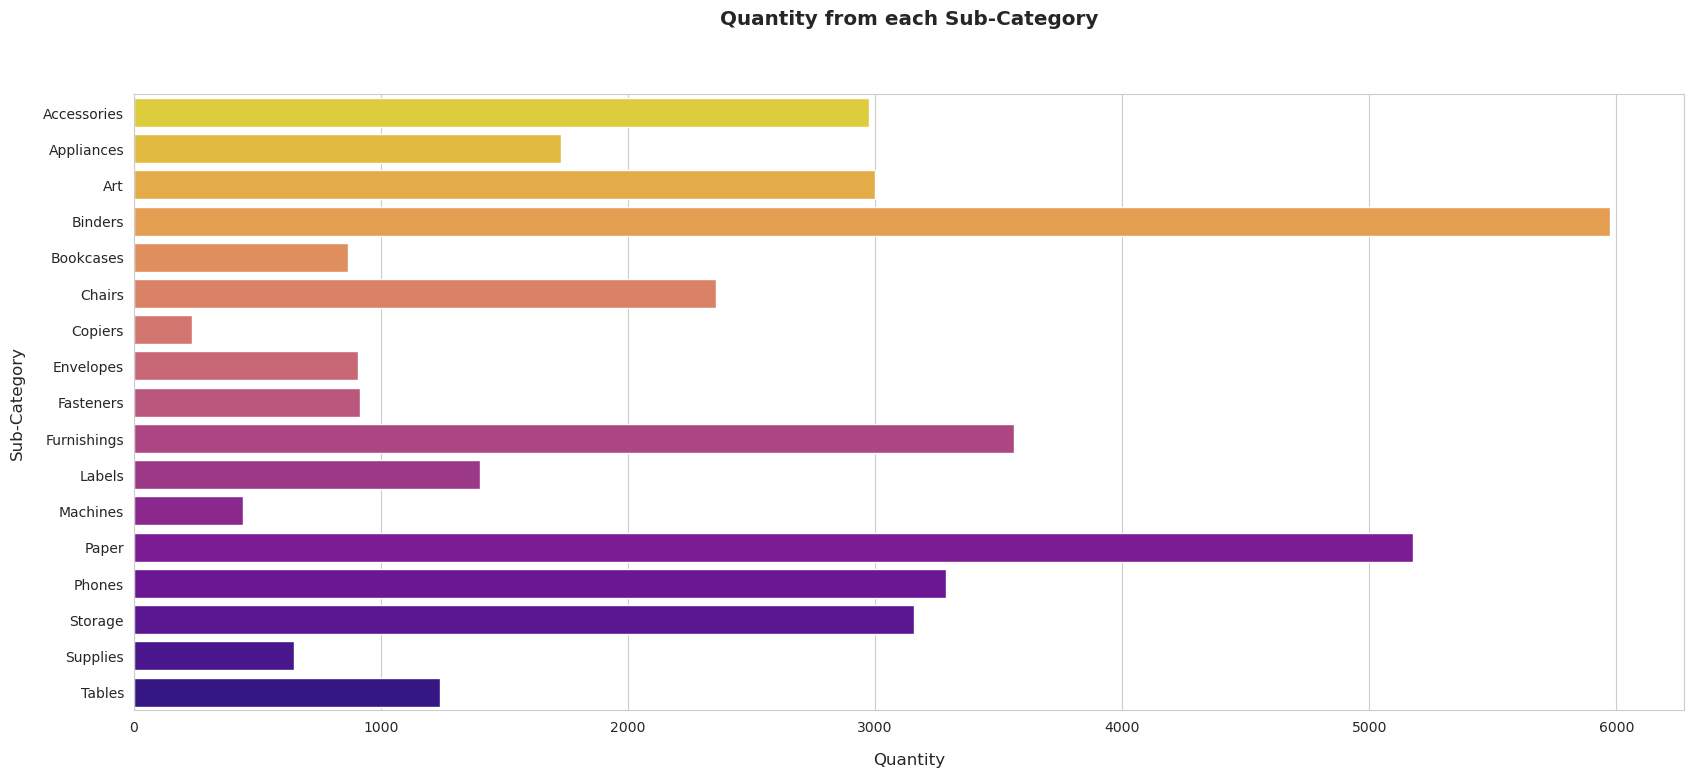

In [23]:
plt.figure(figsize = (20, 8))
sns.barplot(data = df, x = "Quantity", y = "Sub-Category", palette = "plasma_r")

plt.title("Quantity from each Sub-Category", fontsize = "x-large", fontweight = "bold", y = 1.1)
plt.xlabel("Quantity", fontsize = "large", labelpad = 13)
plt.ylabel("Sub-Category", fontsize = "large", labelpad = 13)

plt.show()